<a href="https://colab.research.google.com/github/sansak-123/SanviSaket/blob/main/23BDS0210EDA_phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Gunnels.csv")

df.head()

,rownames,Gunnel,Time,Fromlow,Slope,Rw,Amphiso,Subst,Pool,Water,Cobble
0,1,0,786,190,10,0.1,0,3,0,0,0
1,2,0,794,182,10,0.0,0,3,0,0,0
2,3,0,798,178,20,0.0,0,1,0,0,0
3,4,0,800,176,70,0.3,0,1,0,1,0
4,5,0,804,172,40,0.3,0,1,0,1,0


Applying Basic Statistical Analysis


In [3]:
df.shape

(1592, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1592 entries, 0 to 1591
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  1592 non-null   int64  
 1   Gunnel    1592 non-null   int64  
 2   Time      1592 non-null   int64  
 3   Fromlow   1592 non-null   int64  
 4   Slope     1592 non-null   int64  
 5   Rw        1592 non-null   float64
 6   Amphiso   1592 non-null   int64  
 7   Subst     1592 non-null   int64  
 8   Pool      1592 non-null   int64  
 9   Water     1592 non-null   int64  
 10  Cobble    1592 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 136.9 KB


In [5]:
df.describe()

,rownames,Gunnel,Time,Fromlow,Slope,Rw,Amphiso,Subst,Pool,Water,Cobble
count,1592.000000,1592.000000,1592.000000,1592.000000,1592.000000,1592.000000,1592.000000,1592.000000,1592.000000,1592.000000,1592.000000
mean,796.500000,0.030151,705.243719,149.408920,9.503769,0.527073,0.464196,3.105528,0.202261,0.508794,0.190955
std,459.715129,0.171056,135.853638,82.662326,15.889862,0.421278,0.899039,2.787720,0.401812,0.500080,0.393177
min,1.000000,0.000000,340.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,398.750000,0.000000,623.000000,71.750000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,796.500000,0.000000,712.500000,158.000000,0.000000,0.600000,0.000000,2.000000,0.000000,1.000000,0.000000
75%,1194.250000,0.000000,810.000000,224.250000,10.000000,1.000000,1.000000,4.000000,0.000000,1.000000,0.000000
max,1592.000000,1.000000,983.000000,304.000000,90.000000,1.000000,4.000000,13.000000,1.000000,1.000000,1.000000


In [6]:
df.columns

Index(['rownames', 'Gunnel', 'Time', 'Fromlow', 'Slope', 'Rw', 'Amphiso',
       'Subst', 'Pool', 'Water', 'Cobble'],
      dtype='object')

Missing Data

In [7]:
df.isnull().sum()

,0
rownames,0
Gunnel,0
Time,0
Fromlow,0
Slope,0
Rw,0
Amphiso,0
Subst,0
Pool,0
Water,0


Data Cleaning

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

Data Transformation

All the variables are already stored in the correct numeric form

In [10]:
df = df.copy()

In [11]:
df.reset_index(drop=True, inplace=True)

Univariate analysis with a minimum of three visualizations

Histogram

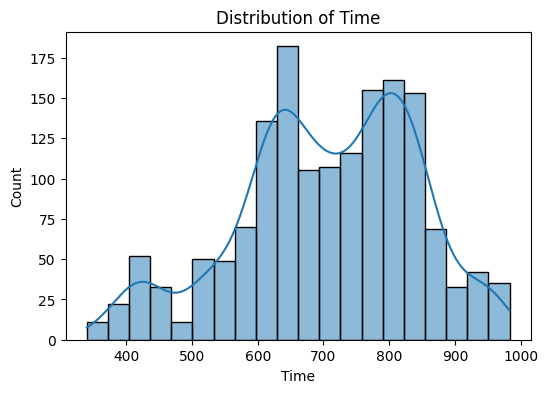

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df["Time"], bins=20, kde=True)
plt.title("Distribution of Time")
plt.show()

Boxplot


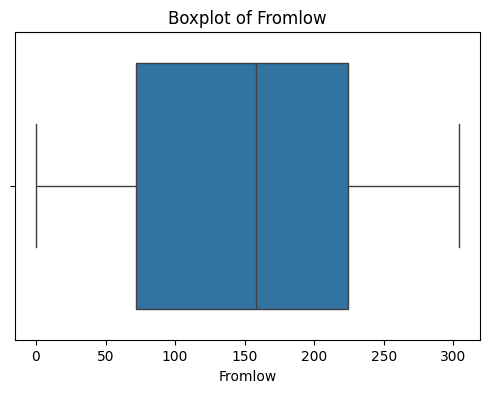

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Fromlow"])
plt.title("Boxplot of Fromlow")
plt.show()

Count Plot

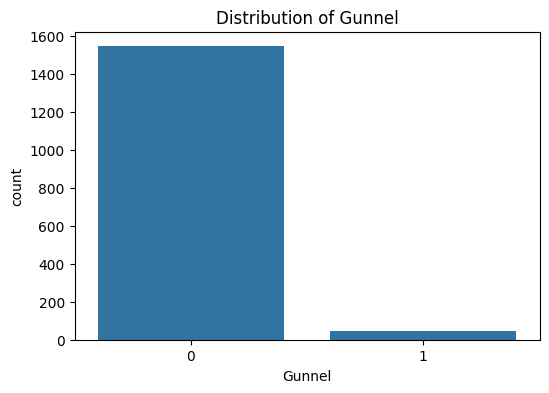

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Gunnel"])
plt.title("Distribution of Gunnel")
plt.show()

Bivariate analysis with a minimum of three visualizations



Scatter Plot

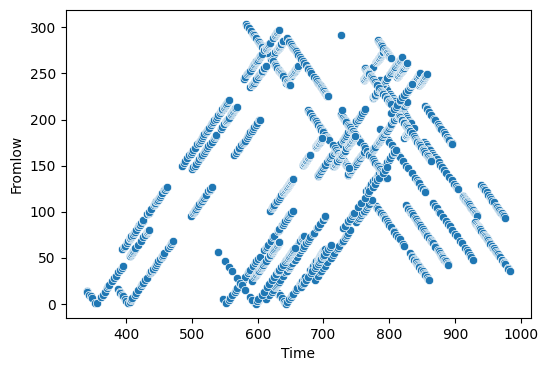

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Time", y="Fromlow")
plt.show()

Box Plot

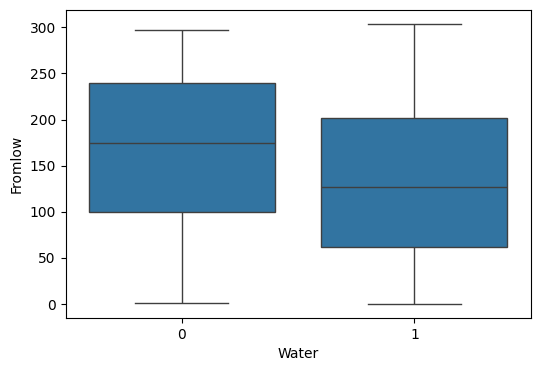

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Water", y="Fromlow")
plt.show()

Bar Plot

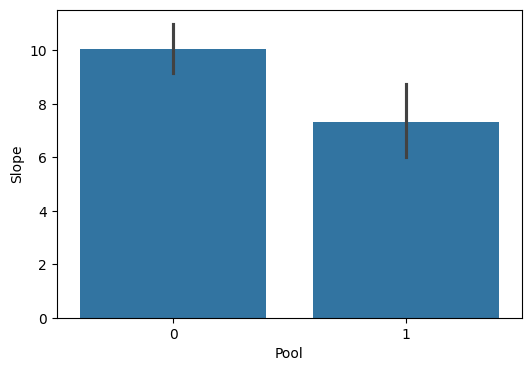

In [17]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="Pool", y="Slope")
plt.show()

Multivariate analysis with a minimum of three visualizations

Coorelation Heatmap

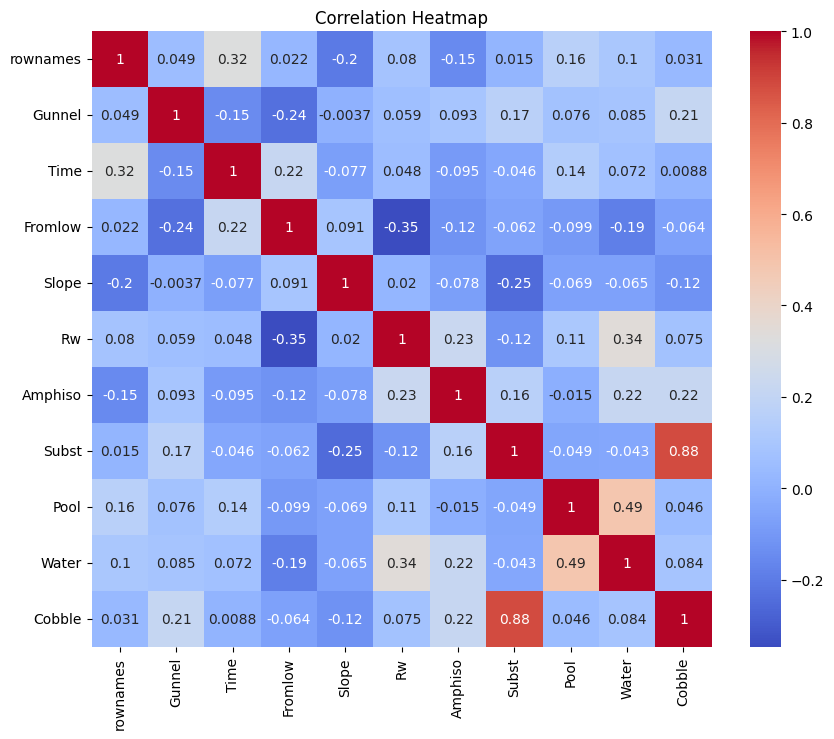

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Pair Plot

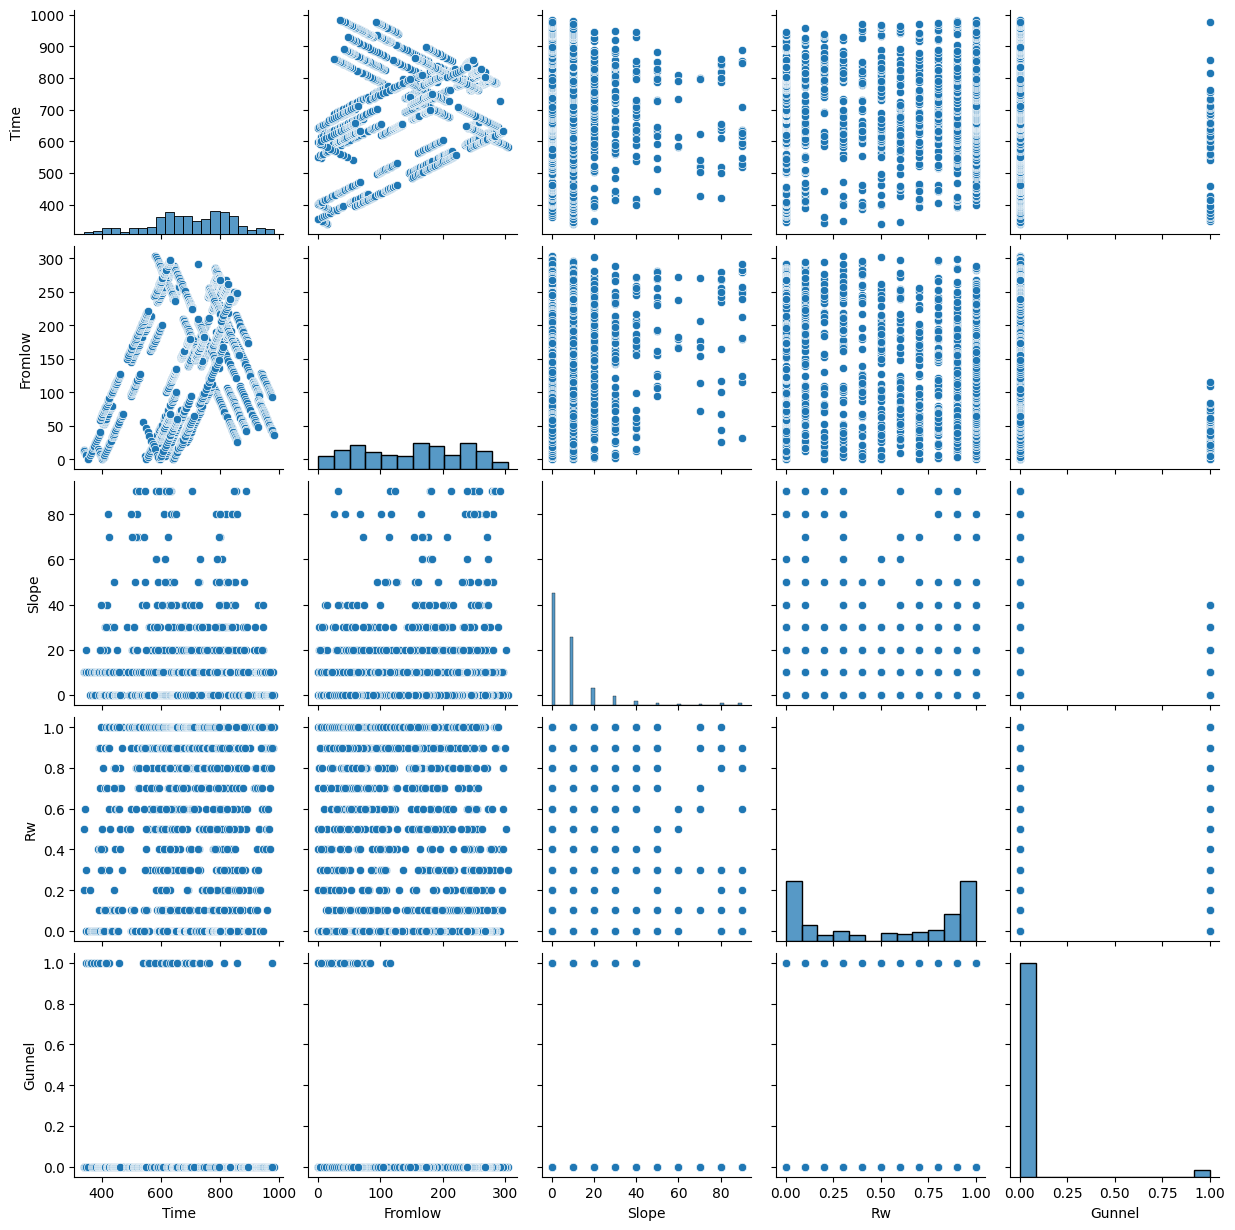

In [19]:
sns.pairplot(df[['Time','Fromlow','Slope','Rw','Gunnel']])
plt.show()

Scatter Plot with Hue

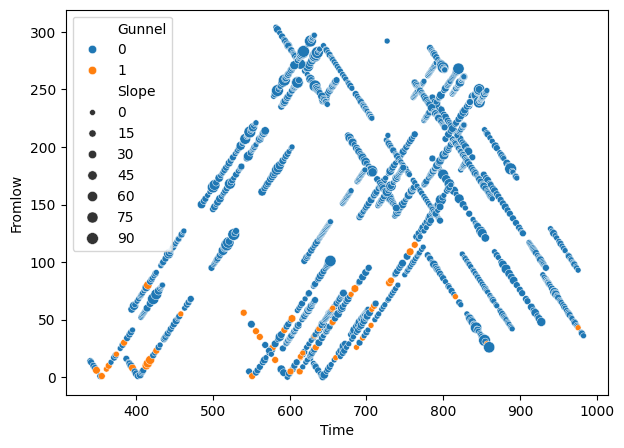

In [20]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="Time",
    y="Fromlow",
    hue="Gunnel",
    size="Slope"
)
plt.show()

PHASE II - STATISTICAL ANALYSIS AND CLUSTERING

1D Statistical Analysis

In [23]:
num = df.select_dtypes(include=np.number)

stats = pd.DataFrame({
    'Mean': num.mean(),
    'Median': num.median(),
    'Mode': num.mode().iloc[0],
    'Variance': num.var(),
    'Std Dev': num.std(),
    'Minimum': num.min(),
    'Q1': num.quantile(0.25),
    'Q3': num.quantile(0.75),
    'Maximum': num.max(),
    'IQR': num.quantile(0.75) - num.quantile(0.25),
    'Skewness': num.skew(),
    'Kurtosis': num.kurtosis()
})

stats

,Mean,Median,Mode,Variance,Std Dev,Minimum,Q1,Q3,Maximum,IQR,Skewness,Kurtosis
rownames,796.500000,796.5,1.0,211338.000000,459.715129,1.0,398.75,1194.25,1592.0,795.5,0.000000,-1.200000
Gunnel,0.030151,0.0,0.0,0.029260,0.171056,0.0,0.00,0.00,1.0,0.0,5.500432,28.290295
Time,705.243719,712.5,827.0,18456.210834,135.853638,340.0,623.00,810.00,983.0,187.0,-0.393544,-0.283849
Fromlow,149.408920,158.0,239.0,6833.060210,82.662326,0.0,71.75,224.25,304.0,152.5,-0.065813,-1.226879
Slope,9.503769,0.0,0.0,252.487729,15.889862,0.0,0.00,10.00,90.0,10.0,2.955768,10.257185
Rw,0.527073,0.6,0.0,0.177475,0.421278,0.0,0.00,1.00,1.0,1.0,-0.143814,-1.726121
Amphiso,0.464196,0.0,0.0,0.808271,0.899039,0.0,0.00,1.00,4.0,1.0,1.949424,3.063898
Subst,3.105528,2.0,1.0,7.771384,2.787720,1.0,1.00,4.00,13.0,3.0,1.229340,0.503901
Pool,0.202261,0.0,0.0,0.161453,0.401812,0.0,0.00,0.00,1.0,0.0,1.483843,0.202043
Water,0.508794,1.0,1.0,0.250080,0.500080,0.0,0.00,1.00,1.0,1.0,-0.035215,-2.001276


Distribution and Outlier Analysis

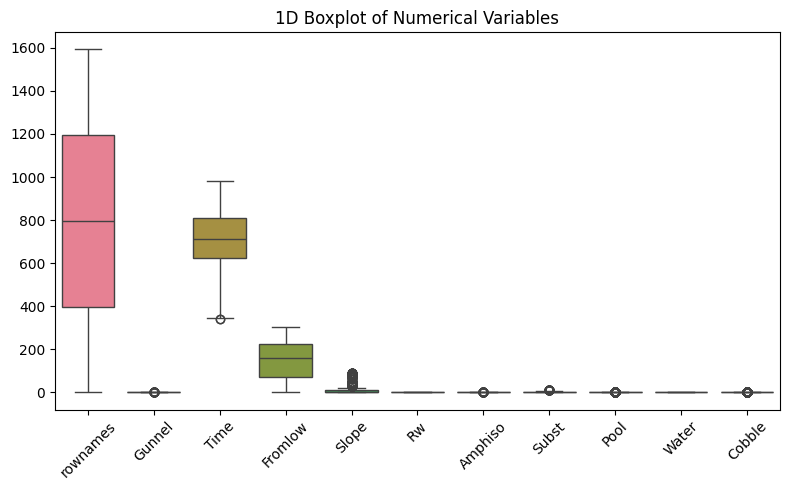

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=num, ax=ax)
ax.set_title('1D Boxplot of Numerical Variables')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

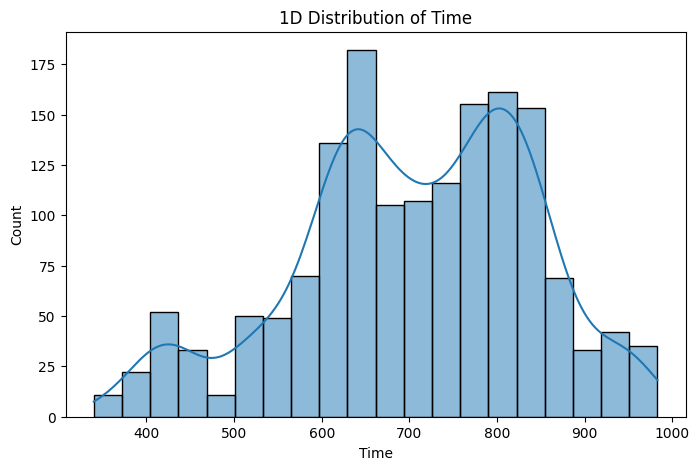

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(df['Time'], kde=True, bins=20, ax=ax)

ax.set_title('1D Distribution of Time')

plt.show()

2D Statistical Analysis

Covariance and Correlation

In [27]:
cov_matrix = num.cov()
corr_matrix = num.corr()

print('Covariance Matrix')
display(cov_matrix)

print('Correlation Matrix')
display(corr_matrix)

Covariance Matrix


,rownames,Gunnel,Time,Fromlow,Slope,Rw,Amphiso,Subst,Pool,Water,Cobble
rownames,211338.000000,3.876807,20148.451288,834.342238,-1472.322439,15.555028,-62.477373,19.053426,29.172847,23.270899,5.588938
Gunnel,3.876807,0.029260,-3.424072,-3.357403,-0.010170,0.004274,0.014279,0.079783,0.005211,0.007277,0.014352
Time,20148.451288,-3.424072,18456.210834,2421.106436,-166.051202,2.736390,-11.597177,-17.245723,7.666576,4.906089,0.470716
Fromlow,834.342238,-3.357403,2421.106436,6833.060210,118.983687,-12.139990,-8.831673,-14.222941,-3.275721,-7.737413,-2.091333
Slope,-1472.322439,-0.010170,-166.051202,118.983687,252.487729,0.130979,-1.120858,-11.085250,-0.440109,-0.520461,-0.778847
Rw,15.555028,0.004274,2.736390,-12.139990,0.130979,0.177475,0.087174,-0.139502,0.018279,0.072515,0.012489
Amphiso,-62.477373,0.014279,-11.597177,-8.831673,-1.120858,0.087174,0.808271,0.400387,-0.005324,0.098681,0.077866
Subst,19.053426,0.079783,-17.245723,-14.222941,-11.085250,-0.139502,0.400387,7.771384,-0.055298,-0.060639,0.967894
Pool,29.172847,0.005211,7.666576,-3.275721,-0.440109,0.018279,-0.005324,-0.055298,0.161453,0.098157,0.007236
Water,23.270899,0.007277,4.906089,-7.737413,-0.520461,0.072515,0.098681,-0.060639,0.098157,0.250080,0.016547


Correlation Matrix


,rownames,Gunnel,Time,Fromlow,Slope,Rw,Amphiso,Subst,Pool,Water,Cobble
rownames,1.000000,0.049300,0.322613,0.021956,-0.201555,0.080318,-0.151166,0.014867,0.157931,0.101224,0.030921
Gunnel,0.049300,1.000000,-0.147345,-0.237442,-0.003742,0.059315,0.092853,0.167311,0.075823,0.085071,0.213397
Time,0.322613,-0.147345,1.000000,0.215593,-0.076922,0.047812,-0.094952,-0.045537,0.140445,0.072215,0.008813
Fromlow,0.021956,-0.237442,0.215593,1.000000,0.090586,-0.348612,-0.118838,-0.061721,-0.098623,-0.187175,-0.064347
Slope,-0.201555,-0.003742,-0.076922,0.090586,1.000000,0.019566,-0.078461,-0.250251,-0.068931,-0.065498,-0.124665
Rw,0.080318,0.059315,0.047812,-0.348612,0.019566,1.000000,0.230164,-0.118785,0.107987,0.344206,0.075399
Amphiso,-0.151166,0.092853,-0.094952,-0.118838,-0.078461,0.230164,1.000000,0.159754,-0.014739,0.219490,0.220282
Subst,0.014867,0.167311,-0.045537,-0.061721,-0.250251,-0.118785,0.159754,1.000000,-0.049367,-0.043498,0.883061
Pool,0.157931,0.075823,0.140445,-0.098623,-0.068931,0.107987,-0.014739,-0.049367,1.000000,0.488495,0.045803
Water,0.101224,0.085071,0.072215,-0.187175,-0.065498,0.344206,0.219490,-0.043498,0.488495,1.000000,0.084158


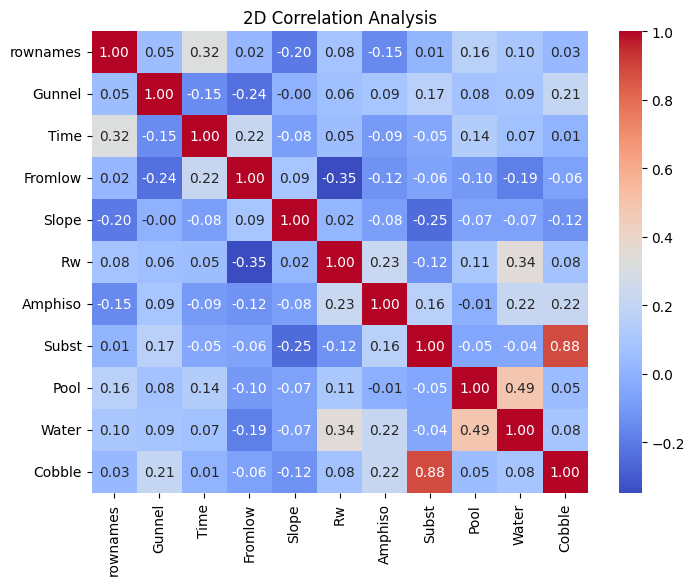

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('2D Correlation Analysis')
plt.show()

Pairwise Relationship Analysis

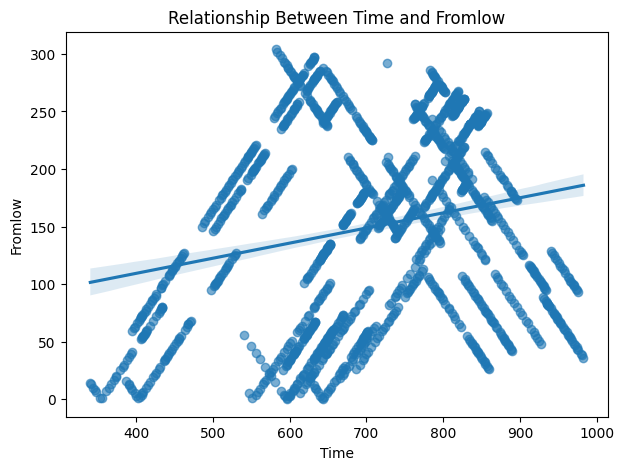

In [29]:
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='Time', y='Fromlow', scatter_kws={'alpha': 0.6})
plt.title('Relationship Between Time and Fromlow')
plt.show()

In [30]:
print('Pearson correlation between Time and Fromlow:', df['Time'].corr(df['Fromlow']))
print('Covariance between Time and Fromlow:', df['Time'].cov(df['Fromlow']))

Pearson correlation between Time and Fromlow: 0.2155931644209428
Covariance between Time and Fromlow: 2421.106435698291


3D Statistical Analysis

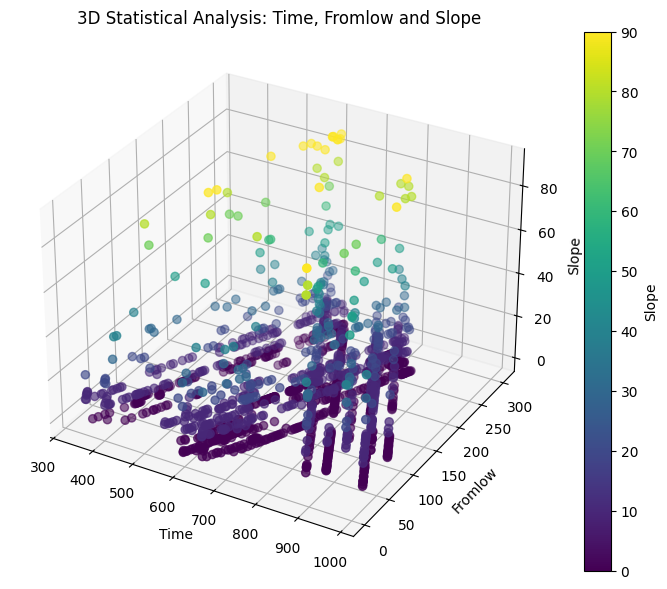

In [31]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(df['Time'], df['Fromlow'], df['Slope'], c=df['Slope'], cmap='viridis', s=35)
ax.set_xlabel('Time')
ax.set_ylabel('Fromlow')
ax.set_zlabel('Slope')
ax.set_title('3D Statistical Analysis: Time, Fromlow and Slope')
fig.colorbar(p, ax=ax, label='Slope')
plt.show()

In [32]:
three_d_corr = df[['Time', 'Fromlow', 'Slope']].corr()
three_d_corr

,Time,Fromlow,Slope
Time,1.000000,0.215593,-0.076922
Fromlow,0.215593,1.000000,0.090586
Slope,-0.076922,0.090586,1.000000


K-Means Clustering

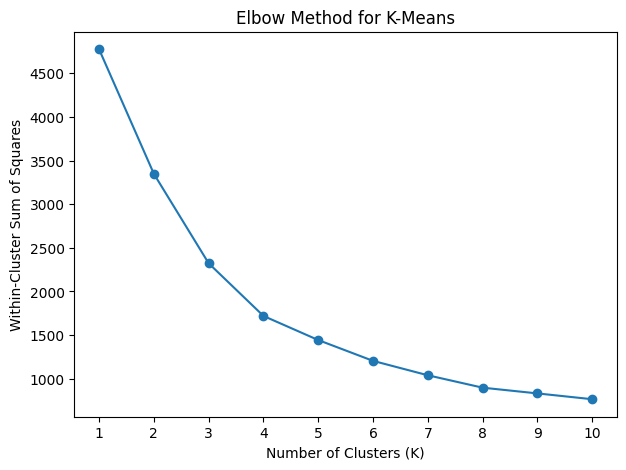

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

x = df[['Time', 'Fromlow', 'Slope']].dropna().copy()

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

inertia = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares')
plt.title('Elbow Method for K-Means')
plt.xticks(list(k_values))
plt.show()

In [34]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(x_scaled)

x['Cluster'] = clusters
df.loc[x.index, 'KMeans_Cluster'] = clusters

x.groupby('Cluster')[['Time', 'Fromlow', 'Slope']].mean()

,Time,Fromlow,Slope
Cluster,,,
0,677.964286,198.071429,63.809524
1,573.982422,71.509766,6.777344
2,775.020080,185.349398,6.325301


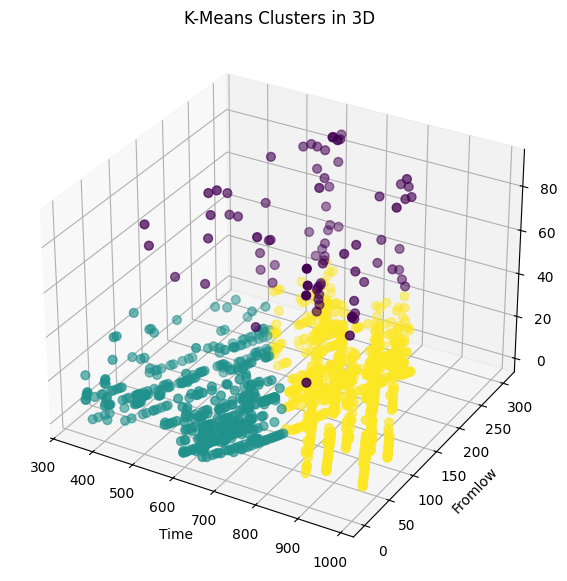

In [35]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(x['Time'], x['Fromlow'], x['Slope'], c=x['Cluster'], cmap='viridis', s=40)
ax.set_xlabel('Time')
ax.set_ylabel('Fromlow')
ax.set_zlabel('Slope')
ax.set_title('K-Means Clusters in 3D')
plt.show()

Hierarchical Clustering

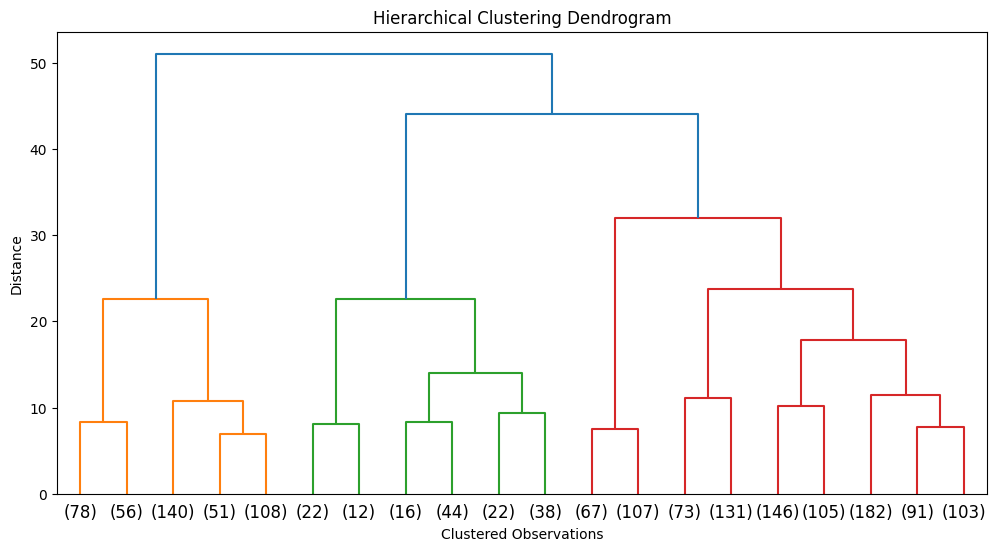

In [36]:
from scipy.cluster.hierarchy import dendrogram, linkage

z = linkage(x_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(z, truncate_mode='lastp', p=20)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Clustered Observations')
plt.ylabel('Distance')
plt.show()

In [37]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
h_labels = hc.fit_predict(x_scaled)

x['Hierarchical_Cluster'] = h_labels
df.loc[x.index, 'Hierarchical_Cluster'] = h_labels

x.groupby('Hierarchical_Cluster')[['Time', 'Fromlow', 'Slope']].mean()

,Time,Fromlow,Slope
Hierarchical_Cluster,,,
0,760.734328,185.054726,4.646766
1,583.625866,52.540416,7.598152
2,685.064935,189.149351,46.558442


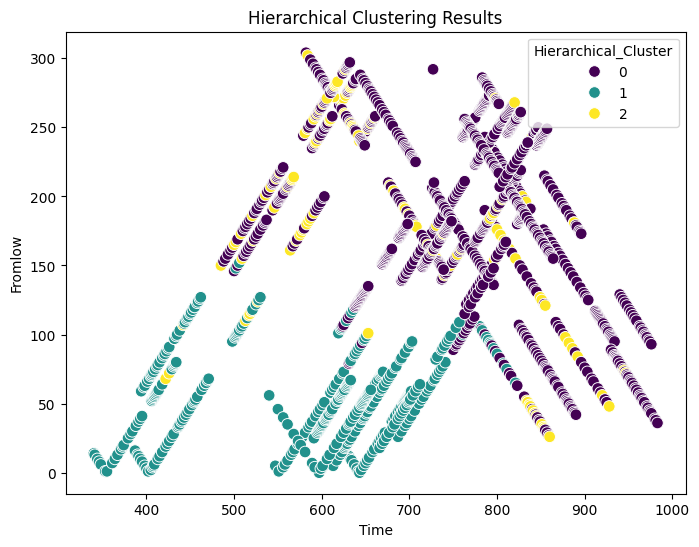

In [38]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=x, x='Time', y='Fromlow', hue='Hierarchical_Cluster', palette='viridis', s=70)
plt.title('Hierarchical Clustering Results')
plt.show()

Phase II Summary:

Phase II extends the exploratory analysis with descriptive 1D statistics, covariance and correlation-based 2D analysis, 3D visualization and statistical relationships, K-Means clustering with the elbow method, and hierarchical clustering using a dendrogram and Ward linkage.